# 🚀 Practice Day 26

**📅 Date:** 2026-10-06  
📁 Category: Phase 3 · 엔드투엔드 미니 파이프라인 (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Run a full mini pipeline end to end — clean two messy tables, merge them, then analyze and visualize the result
  (지저분한 테이블 2개를 정제하고 병합한 뒤 분석·시각화까지 전체 파이프라인을 한 번에 진행하기)
- Find which vehicle category earns the most, how rental duration compares across categories, and which vehicle gets rented the most
  (어떤 차량 카테고리가 가장 많은 매출을 내는지, 카테고리별 대여 기간은 어떻게 다른지, 가장 많이 대여된 차량은 무엇인지 파악하기)

---
# 📂 Dataset

**Dataset Name:** Compass 렌터카 — 차량·대여기록 (2테이블) / Compass Car Rental — Vehicles & Rentals (2 tables)

**Source:** Synthetically generated for practice / 실습을 위해 코드로 생성한 가상 데이터

**Description:** Two messy tables. `vehicles` (40 rows: vehicle_id, model, category) has inconsistent capitalization/whitespace in `category`, plus a few missing values. `rentals` (~310 rows: rental_id, vehicle_id → links to vehicles, customer_id, rental_date, return_date, total_cost in USD) has missing total_cost, missing return_date for rentals not yet returned, and some exact duplicate rows. The core of this file is cleaning both tables, then merging them for analysis.
(지저분한 테이블 2개입니다. `vehicles`(40대: vehicle_id, model, category)는 category 표기가 대소문자·공백 등으로 일관되지 않고 일부는 결측치입니다. `rentals`(약 310건: rental_id, vehicle_id(vehicles와 연결), customer_id, rental_date, return_date, total_cost(USD))는 total_cost 결측, 아직 반납되지 않은 대여의 return_date 결측, 완전 중복행을 포함합니다. 두 테이블을 각각 정제한 뒤 병합해서 분석하는 것이 이 파일의 핵심입니다.)

## Dataset Preview

In [98]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)
rng = np.random.default_rng(42)

# --- vehicles (messy: inconsistent category text, a few missing) ---
categories = ['Economy', 'Compact', 'SUV', 'Luxury', 'Van']
daily_rate = {'Economy': 45, 'Compact': 55, 'SUV': 85, 'Luxury': 180, 'Van': 95}  # USD per day
models_by_cat = {
    'Economy': ['Kona Spark', 'Nova Mini', 'Verve Lite'],
    'Compact': ['Halo Cruz', 'Aster Line', 'Trend GX'],
    'SUV': ['Ridge Trek', 'Summit X7', 'Terra Voyager'],
    'Luxury': ['Aurelia GT', 'Monarch S', 'Zenith Elite'],
    'Van': ['Voyage Max', 'Cargo Pro 8']
}

n_vehicles = 40
veh_per_cat = {c: n_vehicles // len(categories) for c in categories}
for c in list(veh_per_cat.keys())[:n_vehicles % len(categories)]:
    veh_per_cat[c] += 1

veh_rows = []
vid = 1
for cat, cnt in veh_per_cat.items():
    for _ in range(cnt):
        veh_rows.append({'vehicle_id': f'VH{str(vid).zfill(3)}', 'model': rng.choice(models_by_cat[cat]), 'category': cat})
        vid += 1
vehicles = pd.DataFrame(veh_rows)

mess_idx = rng.choice(vehicles.index, size=int(n_vehicles * 0.4), replace=False)
for i in mess_idx:
    base = vehicles.loc[i, 'category']
    vehicles.loc[i, 'category'] = rng.choice([base.lower(), base.upper(), ' ' + base, base + ' '])

miss_idx = rng.choice(vehicles.index, size=3, replace=False)
vehicles.loc[miss_idx, 'category'] = np.nan

# --- rentals (messy: missing total_cost, missing return_date, duplicate rows) ---
n_rentals = 300
rental_ids = [f'RN{str(i).zfill(4)}' for i in range(1, n_rentals + 1)]
veh_choice = rng.choice(vehicles['vehicle_id'].values, size=n_rentals, replace=True)
customer_ids = [f'CU{str(rng.integers(1, 181)).zfill(3)}' for _ in range(n_rentals)]

clean_cat_map = {}
vid2 = 1
for cat, cnt in veh_per_cat.items():
    for _ in range(cnt):
        clean_cat_map[f'VH{str(vid2).zfill(3)}'] = cat
        vid2 += 1

rental_dates = pd.to_datetime('2024-01-01') + pd.to_timedelta(rng.integers(0, 180, size=n_rentals), unit='D')
rental_days = rng.integers(1, 15, size=n_rentals)

rows = []
for i in range(n_rentals):
    vid_ = veh_choice[i]
    cat = clean_cat_map[vid_]
    days = int(rental_days[i])
    r_date = rental_dates[i]
    ret_date = r_date + pd.Timedelta(days=days)
    noise = rng.normal(1.0, 0.08)
    cost = int(round(daily_rate[cat] * days * noise))  # USD
    rows.append({'rental_id': rental_ids[i], 'vehicle_id': vid_, 'customer_id': customer_ids[i],
                 'rental_date': r_date, 'return_date': ret_date, 'total_cost': cost})
rentals = pd.DataFrame(rows)

miss_cost_idx = rng.choice(rentals.index, size=15, replace=False)
rentals.loc[miss_cost_idx, 'total_cost'] = np.nan

avail_idx = rentals.index.difference(miss_cost_idx)
miss_ret_idx = rng.choice(avail_idx, size=10, replace=False)
rentals.loc[miss_ret_idx, 'return_date'] = pd.NaT

dupe_rows = rentals.sample(n=10, random_state=7)
rentals = pd.concat([rentals, dupe_rows], ignore_index=True)
rentals = rentals.sample(frac=1, random_state=99).reset_index(drop=True)

print("Vehicles:")
display(vehicles.head())
print("\nRentals:")
display(rentals.head())


Vehicles:


,vehicle_id,model,category
0,VH001,Kona Spark,Economy
1,VH002,Verve Lite,economy
2,VH003,Nova Mini,Economy
3,VH004,Nova Mini,Economy
4,VH005,Nova Mini,Economy



Rentals:


,rental_id,vehicle_id,customer_id,rental_date,return_date,total_cost
0,RN0037,VH023,CU005,2024-03-28,NaT,690.0
1,RN0103,VH039,CU053,2024-03-18,2024-03-23,418.0
2,RN0051,VH012,CU024,2024-04-24,2024-04-30,337.0
3,RN0003,VH036,CU130,2024-01-17,2024-01-25,722.0
4,RN0108,VH039,CU077,2024-03-20,2024-03-27,604.0


## Dataset Information

In [99]:
# Dataset Information
print("Vehicles:", vehicles.shape)
vehicles.info()
print("\nRentals:", rentals.shape)
rentals.info()

print("\n--- Describe: Vehicles ---")
display(vehicles.describe(include='all'))
print("\n--- Describe: Rentals ---")
display(rentals.describe(include='all'))


Vehicles: (40, 3)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   vehicle_id  40 non-null     str  
 1   model       40 non-null     str  
 2   category    37 non-null     str  
dtypes: str(3)
memory usage: 1.1 KB

Rentals: (310, 6)
<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   rental_id    310 non-null    str           
 1   vehicle_id   310 non-null    str           
 2   customer_id  310 non-null    str           
 3   rental_date  310 non-null    datetime64[us]
 4   return_date  299 non-null    datetime64[us]
 5   total_cost   295 non-null    float64       
dtypes: datetime64[us](2), float64(1), str(3)
memory usage: 14.7 KB

--- Describe: Vehicles ---


,vehicle_id,model,category
count,40,40,37
unique,40,14,17
top,VH001,Trend GX,Economy
freq,1,5,5



--- Describe: Rentals ---


,rental_id,vehicle_id,customer_id,rental_date,return_date,total_cost
count,310,310,310,310,299,295.000000
unique,300,40,149,NaN,NaN,NaN
top,RN0038,VH012,CU167,NaN,NaN,NaN
freq,2,13,7,NaN,NaN,NaN
mean,NaN,NaN,NaN,2024-03-29 14:37:56.129032,2024-04-06 03:36:43.344481,711.647458
min,NaN,NaN,NaN,2024-01-01 00:00:00,2024-01-05 00:00:00,39.000000
25%,NaN,NaN,NaN,2024-02-10 12:00:00,2024-02-15 12:00:00,334.000000
50%,NaN,NaN,NaN,2024-04-02 12:00:00,2024-04-09 00:00:00,588.000000
75%,NaN,NaN,NaN,2024-05-12 00:00:00,2024-05-19 00:00:00,951.500000
max,NaN,NaN,NaN,2024-06-28 00:00:00,2024-07-08 00:00:00,2795.000000


---
# ❓ Business Questions

1. **(Analysis)** After cleaning and merging, which vehicle category generated the most total rental revenue, and which the least?
   (정제·병합 후, 어떤 차량 카테고리가 가장 많은/적은 대여매출을 냈는가?)
2. **(Analysis)** How does average rental duration (in days) differ across vehicle categories?
   (카테고리별 평균 대여기간(일수)은 어떻게 다른가?)
3. **(Analysis)** Which specific vehicle has been rented the most times, and how many times?
   (가장 많이 대여된 차량은 무엇이며, 몇 번 대여되었는가?)
4. **(Visualization)** Compare total revenue across all vehicle categories.
   (차량 카테고리별 총매출을 비교하면?)
5. **(Visualization)** Show how the number of rentals moves month to month.
   (월별 대여 건수는 어떻게 변화하는가?)

---
# 🔍 Data Cleaning Check


In [100]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== vehicles =====")
print("Missing values")
print(vehicles.isnull().sum())
print("\nDuplicate rows:", vehicles.duplicated().sum())
print("\nDtypes")
print(vehicles.dtypes)
print("\nColumn names")
print(vehicles.columns.tolist())
obj_cols = vehicles.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(vehicles[obj_cols].nunique())
print()

print("===== rentals =====")
print("Missing values")
print(rentals.isnull().sum())
print("\nDuplicate rows:", rentals.duplicated().sum())
print("\nDtypes")
print(rentals.dtypes)
print("\nColumn names")
print(rentals.columns.tolist())
obj_cols = rentals.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(rentals[obj_cols].nunique())
print()


===== vehicles =====
Missing values
vehicle_id    0
model         0
category      3
dtype: int64

Duplicate rows: 0

Dtypes
vehicle_id    str
model         str
category      str
dtype: object

Column names
['vehicle_id', 'model', 'category']

Text columns — unique counts
vehicle_id    40
model         14
category      17
dtype: int64

===== rentals =====
Missing values
rental_id       0
vehicle_id      0
customer_id     0
rental_date     0
return_date    11
total_cost     15
dtype: int64

Duplicate rows: 10

Dtypes
rental_id                 str
vehicle_id                str
customer_id               str
rental_date    datetime64[us]
return_date    datetime64[us]
total_cost            float64
dtype: object

Column names
['rental_id', 'vehicle_id', 'customer_id', 'rental_date', 'return_date', 'total_cost']

Text columns — unique counts
rental_id      300
vehicle_id      40
customer_id    149
dtype: int64



---
# 📊 Analysis

## Question 1

**Question:** After cleaning and merging, which vehicle category generated the most total rental revenue, and which the least? (정제·병합 후 최고·최저 매출 카테고리는?)

**Result:** Luxury **$80,518**, SUV **$36,241**, Van **$32,968**, Compact **$24,746**, Economy **$20,805**.
(Luxury $80,518, SUV $36,241, Van $32,968, Compact $24,746, Economy $20,805)

**Insight:** Luxury is the top category even though it has fewer vehicles than Economy or Compact. Its $180/day rate is about 2–4x the other categories, so revenue tracks price more than rental count.
(차량 수가 Economy·Compact보다 적은데도 Luxury가 1위. 일당 $180 요금이 다른 카테고리보다 2~4배 높아 매출이 그만큼 따라옴)

In [101]:
# Question 1: total revenue by category (after cleaning + merging)

vehicles['category'].value_counts()

cleaned_vehicles = vehicles.copy()
cleaned_vehicles['category'] = cleaned_vehicles['category'].str.strip().str.title()
cleaned_vehicles['category'] = cleaned_vehicles['category'].str.replace('Suv', 'SUV')

cleaned_vehicles['category'].value_counts()

category
Economy    8
SUV        8
Compact    7
Luxury     7
Van        7
Name: count, dtype: int64

In [102]:
display(cleaned_vehicles['category'].value_counts())
display(cleaned_vehicles[cleaned_vehicles['category'].isna()])
display(cleaned_vehicles[cleaned_vehicles['model'].isin(['Trend GX', 'Monarch S', 'Cargo Pro 8'])])

cleaned_vehicles.loc[cleaned_vehicles['model'] == 'Trend GX', 'category'] = 'Compact'
cleaned_vehicles.loc[cleaned_vehicles['model'] == 'Monarch S', 'category'] = 'Luxury'
cleaned_vehicles.loc[cleaned_vehicles['model'] == 'Cargo Pro 8', 'category'] = 'Van'

cleaned_vehicles['category'].value_counts()

merged_df = pd.merge(cleaned_vehicles, rentals, on='vehicle_id', how='left')

category
Economy    8
SUV        8
Compact    7
Luxury     7
Van        7
Name: count, dtype: int64

,vehicle_id,model,category
11,VH012,Trend GX,NaN
29,VH030,Monarch S,NaN
33,VH034,Cargo Pro 8,NaN


,vehicle_id,model,category
11,VH012,Trend GX,NaN
12,VH013,Trend GX,Compact
13,VH014,Trend GX,Compact
14,VH015,Trend GX,Compact
15,VH016,Trend GX,Compact
25,VH026,Monarch S,Luxury
26,VH027,Monarch S,Luxury
28,VH029,Monarch S,Luxury
29,VH030,Monarch S,NaN
30,VH031,Monarch S,Luxury


In [103]:
print(f"{merged_df['total_cost'].isna().sum() / len(merged_df) * 100:.2f}% of rentals have missing total_cost")
print(f"{merged_df['return_date'].isna().sum() / len(merged_df) * 100:.2f}% of rentals have missing return_date")

print(merged_df[merged_df['total_cost'].isna()]['category'].value_counts() / merged_df['category'].value_counts() * 100)
print(merged_df[merged_df['return_date'].isna()]['category'].value_counts() / merged_df['category'].value_counts() * 100)

print(merged_df.groupby('category').size() - merged_df[merged_df['total_cost'].isna()]['category'].value_counts(), merged_df[merged_df['return_date'].isna()]['category'].value_counts())

# Decision: missing total_cost/return_date is ~5% and not concentrated in one category
# (each category keeps 46+ rows after dropping) -> drop rather than estimate from noisy daily_rate.
print("\nBefore drop:", merged_df.shape)
print("Exact duplicate rows:", merged_df.duplicated().sum())

clean_df = merged_df.drop_duplicates()
clean_df = clean_df.dropna(subset=['total_cost', 'return_date'])

print("After drop:", clean_df.shape)
clean_df['category'].value_counts()

total_revenue_by_category = clean_df.groupby('category')['total_cost'].sum().sort_values(ascending=False)
total_revenue_by_category

4.84% of rentals have missing total_cost
3.55% of rentals have missing return_date
category
Compact    3.389831
Economy    4.615385
Luxury     6.250000
SUV        1.470588
Van        9.259259
Name: count, dtype: float64
category
Compact         NaN
Economy    3.076923
Luxury     1.562500
SUV        7.352941
Van        5.555556
Name: count, dtype: float64
category
Compact    57
Economy    62
Luxury     60
SUV        67
Van        49
dtype: int64 category
SUV        5
Van        3
Economy    2
Luxury     1
Name: count, dtype: int64

Before drop: (310, 8)
Exact duplicate rows: 10
After drop: (275, 8)


category
Luxury     80518.0
SUV        36241.0
Van        32968.0
Compact    24746.0
Economy    20805.0
Name: total_cost, dtype: float64

## Question 2

**Question:** How does average rental duration (in days) differ across vehicle categories? (카테고리별 평균 대여기간은?)

**Result:** Compact **8.09** days, Van **7.98**, Economy **7.91**, Luxury **7.84**, SUV **7.15**.
(Compact 8.09일, Van 7.98, Economy 7.91, Luxury 7.84, SUV 7.15)

**Insight:** The five averages sit close together, within about **1** day of each other. Rental duration doesn't vary much by category.
(다섯 평균이 약 1일 안에서 거의 비슷함. 대여기간은 카테고리별 차이가 거의 없음)

In [104]:
# Question 2: average rental duration (days) by category

clean_df['rental_days'] = (clean_df['return_date'] - clean_df['rental_date']).dt.days
avg_days_by_category = clean_df.groupby('category')['rental_days'].mean().round(2).sort_values(ascending=False)
avg_days_by_category


category
Compact    8.09
Van        7.98
Economy    7.91
Luxury     7.84
SUV        7.15
Name: rental_days, dtype: float64

## Question 3

**Question:** Which specific vehicle has been rented the most times, and how many times? (가장 많이 대여된 차량과 횟수는?)

**Result:** `VH012` (Trend GX) is the most-rented vehicle, **12** times. Next are `VH027` (Monarch S) and `VH004` (Nova Mini), each **11**.
(VH012(Trend GX)가 가장 많은 12회. 그다음은 VH027(Monarch S), VH004(Nova Mini)가 각 11회)

**Insight:** `VH012` is the Compact that originally had a missing category before cleaning. Fixing that label mattered — without it, this vehicle's rentals would sit outside any category total.
(VH012는 정제 전에 category가 비어 있던 Compact 차량이었음. 그 값을 고쳐주지 않았다면 이 차량의 대여건은 어느 카테고리 합산에도 안 잡혔을 것)

In [105]:
# Question 3: most-rented vehicle (by rental count)

rental_counts = clean_df.groupby(['vehicle_id', 'model']).size().sort_values(ascending=False)
rental_counts.head(5)


vehicle_id  model     
VH012       Trend GX      12
VH027       Monarch S     11
VH004       Nova Mini     11
VH023       Ridge Trek    10
VH018       Ridge Trek    10
dtype: int64

---
# 📈 Visualization

**Chart 1:** Bar chart — total revenue by category (막대그래프: 카테고리별 총매출)

*Interpretation:* Luxury's bar is tallest at **$80,518**, roughly **2.2x** SUV ($36,241) and **3.9x** Economy ($20,805). The gap between the other four categories is much smaller than the gap to Luxury.
(Luxury $80,518이 가장 높음. SUV의 약 2.2배, Economy의 약 3.9배. 나머지 네 카테고리 간 격차는 Luxury와의 격차보다 훨씬 작음)

---

**Chart 2:** Line chart — monthly rental count (선그래프: 월별 대여건수 추이)

*Interpretation:* Rental dates were drawn uniformly over a 180-day window (2024-01-01 to 2024-06-28), so the monthly line moves without a clear seasonal pattern.
(대여 날짜가 180일 구간에서 고르게 뽑혀, 월별 선은 뚜렷한 계절 패턴 없이 들쭉날쭉함)

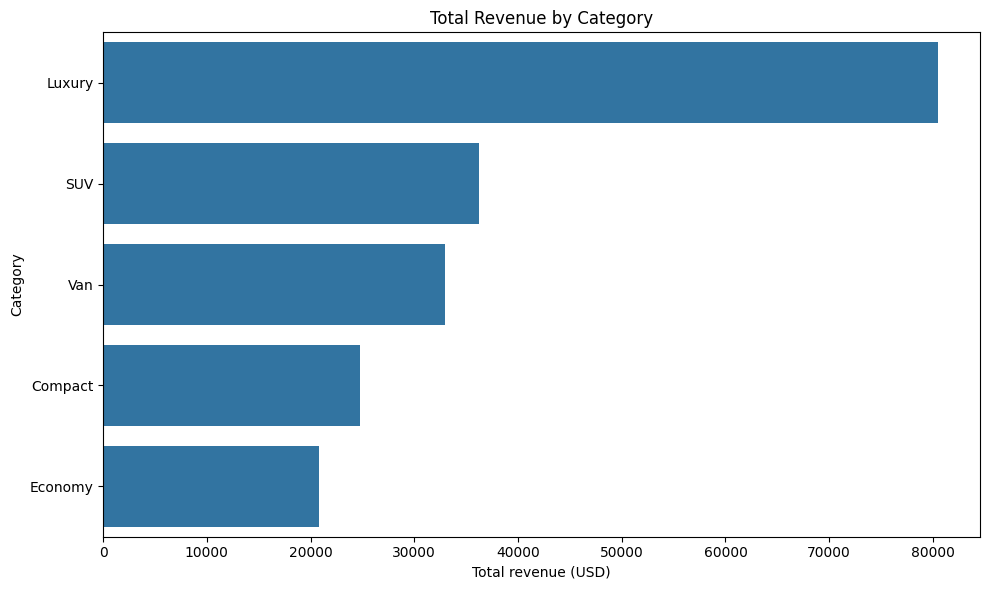

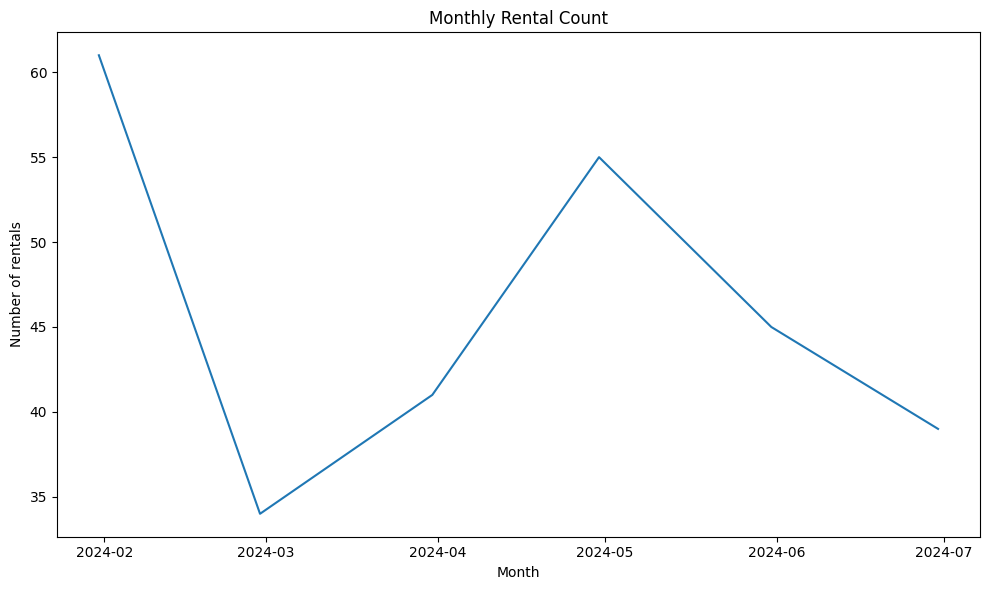

In [106]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: total revenue by category (bar)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=total_revenue_by_category.values, y=total_revenue_by_category.index, ax=ax)
ax.set_title('Total Revenue by Category')
ax.set_xlabel('Total revenue (USD)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

# Chart 2: monthly rental count (line)
monthly_rentals = clean_df.set_index('rental_date').resample('ME').size()
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x=monthly_rentals.index, y=monthly_rentals.values, ax=ax)
ax.set_title('Monthly Rental Count')
ax.set_xlabel('Month')
ax.set_ylabel('Number of rentals')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- Luxury drives the most revenue (**$80,518**) despite not having the most vehicles — its $180/day rate is 2–4x the other categories.
  (Luxury가 매출 1위($80,518). 차량 수는 많지 않지만 일일 $180 요금이 다른 카테고리의 2~4배)
- Rental duration barely differs by category — all five averages sit within about 1 day (7.15–8.09 days).
  (카테고리별 평균 대여기간은 거의 같음. 7.15~8.09일로 약 1일 차이)
- `VH012` is the most-rented vehicle (**12** times) — it's also the Compact that had a missing category before cleaning.
  (VH012가 가장 많이 대여됨(12회). 정제 전 category가 비어 있던 차량이기도 함)

---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Prioritize growing the Luxury fleet, since its per-day rate makes it the top revenue category by a wide margin.
   (Luxury 차량을 늘리기. 일일 요금 덕에 매출 1위를 크게 앞섬)
2. Don't price rental-duration promotions by category — duration doesn't vary enough (within 1 day) to justify it.
   (대여기간 기준 카테고리별 프로모션은 두지 않기. 카테고리 간 차이가 1일 이내로 작음)
3. Keep category labels clean at data entry — a blank category hid `VH012`'s rentals from the Compact total until it was fixed.
   (입력 시 category를 비워두지 않기. VH012는 고치기 전까지 Compact 총계에서 빠져 있었음)

---
# ❌ Mistakes
*What mistakes did I make today?*

- Used `.str.title()` to clean `category`, which turned `SUV` into `Suv` because title-casing lowercases every letter after the first.
  (category 정제에 .str.title()을 썼는데, 모든 대문자 단어의 첫 글자만 남기고 나머지를 소문자로 바꿔 SUV가 Suv가 됨)
- Almost filled missing `total_cost`/`return_date` by reversing `daily_rate × days`, forgetting that the original value includes ±8% random noise, so the reversal would only be an estimate.
  (total_cost·return_date 결측을 daily_rate × days로 역산해 채우려 했는데, 원래 값에 ±8% 노이즈가 섞여 있어 역산해도 추정값일 뿐임)

---
# ✅ What I Learned
*Today's biggest lesson*

- `.str.title()` lowercases every letter after the first in each word, so all-caps codes like `SUV` need a separate fix.
  (.str.title()은 각 단어 첫 글자만 남기고 나머지를 소문자로 바꿈. SUV 같은 전부 대문자 코드는 따로 고쳐야 함)
- Before deciding to drop or impute missing values, check the missing rate per group (here, by category), not just the overall rate.
  (결측을 버릴지 채울지 정하기 전에, 전체 비율만 보지 말고 그룹별(카테고리별) 비율을 확인해야 함)
- If a value was generated with random noise, reversing a formula to fill a gap only gives an estimate, not the real value.
  (값이 난수로 생성된 거라면, 공식을 거꾸로 풀어 메워도 실제값이 아니라 추정값일 뿐임)

---
# 🧠 Reflection

**What was difficult?**
Deciding whether to drop or estimate the missing `total_cost` and `return_date` rows.
(total_cost·return_date 결측을 버릴지 추정할지 정하는 것)

**Why?**
Both looked recoverable from the other columns at first glance, but the cost formula has built-in noise, so any reversal would be an estimate, not the true value.
(겉보기엔 다른 열로 복원 가능해 보였지만, 비용 공식에 노이즈가 섞여 있어 역산해도 추정값일 뿐임)

**How did I solve it?**
Checked the missing rate overall (under 5%) and by category (46+ rows remain in the smallest category), then dropped the rows since no category would be left too thin.
(전체 결측률(5% 미만)과 카테고리별 결측률을 확인했고, 가장 적은 카테고리도 46건 이상 남아 그냥 버리기로 함)

**What would I do differently next time?**
Check for a case-sensitivity trap in `.str.title()` before trusting a category clean-up, since all-caps codes break under it.
(category 정제를 바로 믿기 전에 .str.title()이 전부 대문자인 코드에서 깨지는지 먼저 확인하기)

---
# ⭐ Self Evaluation

**Understanding**
★★★★★★★☆☆☆
Cleaning two tables, merging, and deciding drop-vs-impute by category share are clear.
(두 테이블 정제, 병합, 카테고리별 비율로 버릴지 정하는 것은 이해함)

**Confidence**
★★★★★★☆☆☆☆

**Difficulty**
★★★★★★★☆☆☆
Catching the `.str.title()` SUV bug and reasoning about the noise in `total_cost` were the new parts.
(.str.title()의 SUV 버그를 잡은 것과 total_cost의 노이즈를 따지는 것이 새로웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 27 — Capstone 1: RFM analysis (Round 2/5)
  (캡스톤 1 — RFM 분석 복습)